## Libraries and constants

In [226]:
# Source - https://stackoverflow.com/a/9031848
# Posted by astrofrog, modified by community. See post 'Timeline' for change history
# Retrieved 2026-04-27, License - CC BY-SA 4.0
import warnings
warnings.filterwarnings('ignore')


TMINUS = '2014-01-01' 
START = '2015-01-01'
END = '2024-12-31'

YEARLY_TRADING_DATES = 252 # n
MONTHLY_TRADING_DATES = YEARLY_TRADING_DATES / 12 # = 21 trading days/month
T_FACTOR = MONTHLY_TRADING_DATES / YEARLY_TRADING_DATES # (1+r/n)^{t_factor*n}

MONEYNESS = {'CC': 1.02, 'PP': 0.98}

## Yahoo Finance scraping and Feature engineering

In [235]:
import yfinance as yf
import pandas as pd
tickers = ['^GSPC', '^VIX', '^TYX']
# Documentation: https://ranaroussi.github.io/yfinance/reference/api/yfinance.download.html#yfinance.download
df = yf.download(tickers, start=TMINUS, end=END, interval='1d',multi_level_index=True)
# Inspiration from https://www.kaggle.com/code/alessandrozanette/s-p500-analysis-using-yfinance-data
df = df.drop(columns=['High', 'Low', 'Open', 'Volume']) # Irrelevant columns
for ticker in tickers:
    if ticker != "^GSPC":
        df.loc[:, ('Close', ticker)] = df.loc[:, ('Close', ticker)] / 100 # From percent to decimal

# Source - https://stackoverflow.com/a/43896326
# Posted by MaxU - stand with Ukraine
# Retrieved 2026-04-27, License - CC BY-SA 3.0

newCols = {'Close_^GSPC': 'sp500', 'Close_^VIX': 'sigma', 'Close_^TYX': 'rf'} # rf = risk free rate
df.columns = df.columns.map('_'.join).to_series().map(newCols)

df

# sp500.tail() # shows the last values
# sp500.describe() # count, max, min, std etc

# # Inspiration: Source - https://stackoverflow.com/a/50563791
# # Posted by jezrael, modified by community. See post 'Timeline' for change history
# # Retrieved 2026-04-24, License - CC BY-SA 4.0
# sp500['daily_return'] = sp500['Close'].div(sp500['Close'].shift(1))-1
# # use df.loc for indexing https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.loc.html
# sp500.loc['2016-04-25 00:00:00-04:00','daily_return'] = 0

# # Inspiration from https://www.kaggle.com/code/alessandrozanette/s-p500-analysis-using-yfinance-data
# # Volatility
# sp500['volatility'] = sp500['daily_return'].rolling(window=252).std() * (252 ** 0.5)

# # Source - https://stackoverflow.com/a/72240529
# # Posted by jinx, modified by community. See post 'Timeline' for change history
# # Retrieved 2026-04-24, License - CC BY-SA 4.0
# sp500.reset_index(inplace=True)
# sp500['Date'] = sp500['Date'].dt.strftime('%Y-%m-%d')
# sp500['Date'] = pd.to_datetime(sp500['Date'])

# sp500 = sp500[sp500['Date'] > '2016-04-23'] # remove older dates
# sp500.reset_index(inplace=True)
# sp500 = sp500.drop(columns=['index'])

# # Inspiration: Source - https://stackoverflow.com/a/57620144
# # Posted by Chris
# # Retrieved 2026-04-24, License - CC BY-SA 4.0
# sp500['compounded_return (%)'] = ((sp500['daily_return'].add(1)).cumprod()-1)*100
# sp500

[*********************100%***********************]  3 of 3 completed


,sp500,rf,sigma
Date,,,
2014-01-02,1831.979980,0.03919,0.1423
2014-01-03,1831.369995,0.03930,0.1376
2014-01-06,1826.770020,0.03898,0.1355
2014-01-07,1837.880005,0.03881,0.1292
2014-01-08,1837.489990,0.03903,0.1287
...,...,...,...
2024-12-23,5974.069824,0.04784,0.1678
2024-12-24,6040.040039,0.04765,0.1427
2024-12-26,6037.589844,0.04762,0.1473


## Black-Scholes

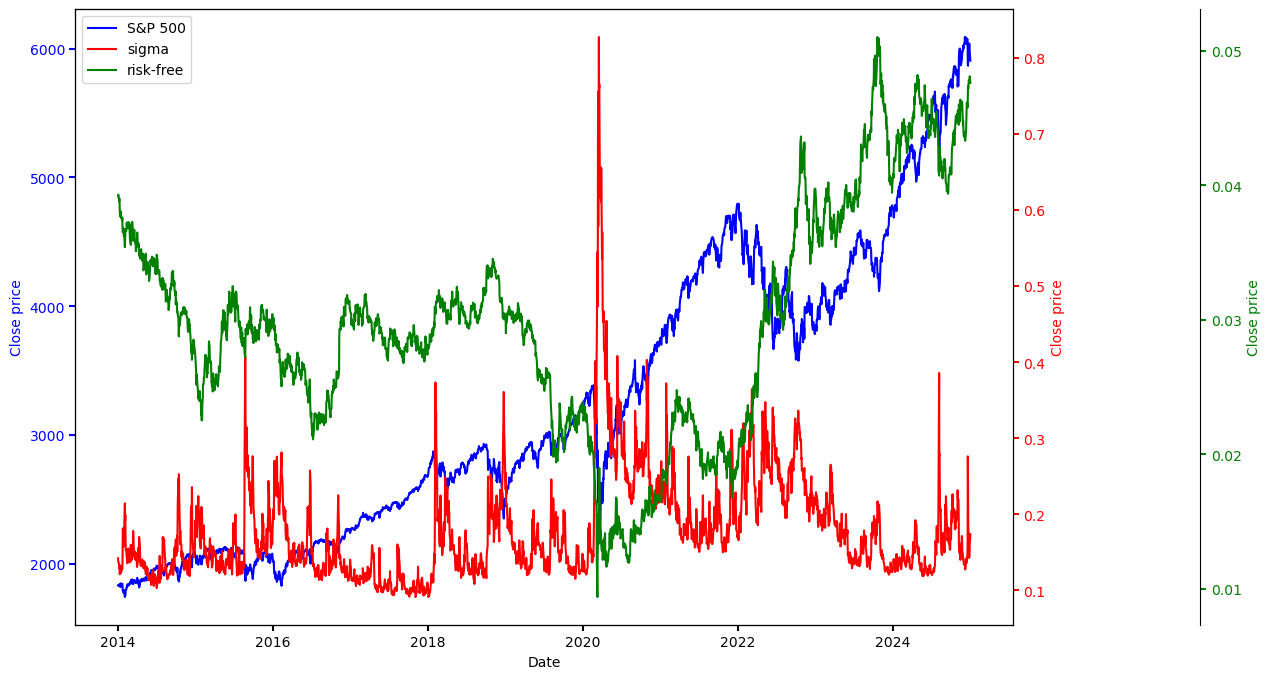

In [228]:
import matplotlib.pyplot as plt

# Source - https://stackoverflow.com/a/14770827
# Posted by Rutger Kassies, modified by community. See post 'Timeline' for change history
# Retrieved 2026-04-27, License - CC BY-SA 4.0
fig, ax = plt.subplots(figsize=(15, 8))

# Plot inspiration from: https://matplotlib.org/3.4.3/gallery/ticks_and_spines/multiple_yaxis_with_spines.html
fig.subplots_adjust(right=0.75)

twin1 = ax.twinx()
twin2 = ax.twinx()
twin2.spines.right.set_position(("axes", 1.2))

p1, = ax.plot(df['sp500'], "b-", label="S&P 500")
p2, = twin1.plot(df['sigma'], "r-", label="sigma")
p3, = twin2.plot(df['rf'], "g-", label="risk-free")

ax.set_xlabel("Date")
ax.set_ylabel("Close price")
twin1.set_ylabel("Close price")
twin2.set_ylabel("Close price")

ax.yaxis.label.set_color(p1.get_color())
twin1.yaxis.label.set_color(p2.get_color())
twin2.yaxis.label.set_color(p3.get_color())

tkw = dict(size=4, width=1.5)
ax.tick_params(axis='y', colors=p1.get_color(), **tkw)
twin1.tick_params(axis='y', colors=p2.get_color(), **tkw)
twin2.tick_params(axis='y', colors=p3.get_color(), **tkw)
ax.tick_params(axis='x', **tkw)

ax.legend(handles=[p1, p2, p3])

plt.show()

In [ ]:
# Taken from: https://theaiquant.medium.com/mastering-the-black-scholes-model-with-python-a-comprehensive-guide-to-option-pricing-11af712697b7
import numpy as np
import scipy.stats as si
import mplfinance as mpf
import plotly.graph_objects as go
from datetime import datetime

class BlackScholesModel:
    def __init__(self, S, K, T, r, sigma):
        self.S = S        # Underlying asset price
        self.K = K        # Option strike price
        self.T = T        # Time to expiration in years
        self.r = r        # Risk-free interest rate
        self.sigma = sigma  # Volatility of the underlying asset

    def d1(self):
        return (np.log(self.S / self.K) + (self.r + 0.5 * self.sigma ** 2) * self.T) / (self.sigma * np.sqrt(self.T))
    
    def d2(self):
        return self.d1() - self.sigma * np.sqrt(self.T)
    
    def call_option_price(self):
        return (self.S * si.norm.cdf(self.d1(), 0.0, 1.0) - self.K * np.exp(-self.r * self.T) * si.norm.cdf(self.d2(), 0.0, 1.0))
    
    def put_option_price(self):
        return (self.K * np.exp(-self.r * self.T) * si.norm.cdf(-self.d2(), 0.0, 1.0) - self.S * si.norm.cdf(-self.d1(), 0.0, 1.0))


def calculate_historical_volatility(stock_data, window=252):
    log_returns = np.log(stock_data / stock_data.shift(1))
    volatility = np.sqrt(window) * log_returns.std()
    return volatility

# Lambda functions + pandas apply: Source - https://stackoverflow.com/a/60125623
# Posted by Araldo van de Kraats
# Retrieved 2026-04-27, License - CC BY-SA 4.0

df['Call (VIX vol)'] = df.apply(lambda x: BlackScholesModel(S = x.sp500, K = x.sp500*MONEYNESS['CC'], T = 1, r = x.rf, sigma = x.sigma).call_option_price(), axis=1)
df['Put (VIX vol)'] = df.apply(lambda x: BlackScholesModel(S = x.sp500, K = x.sp500*MONEYNESS['PP'], T = 1, r = x.rf, sigma = x.sigma).put_option_price(), axis=1)

df['Historical vol'] = df['sp500'].rolling(window=252, min_periods=252).apply(calculate_historical_volatility)
# df = df.dropna() # remove tminus after first run
# df['vol diff'] = df['sigma'] - df['Historical vol']


# Source - https://stackoverflow.com/a/28681097
# Posted by Adam Smith, modified by community. See post 'Timeline' for change history
# Retrieved 2026-04-24, License - CC BY-SA 3.0

import calendar

c = calendar.Calendar(firstweekday=calendar.SUNDAY)

df['Date'] = df.index
year = df['Date'].min().year
month = df['Date'].min().month

fridays = df[df['Date'] > '3000-04-23']

while(year <= df['Date'][len(df['Date'])-1].year):
    monthcal = c.monthdatescalendar(year,month)
    third_friday = [day for week in monthcal for day in week if \
                    day.weekday() == calendar.FRIDAY and \
                    day.month == month][2]
    fridays = pd.concat([fridays, df[df['Date'] == str(third_friday)]], ignore_index=True)
    if month == 12:
        month = 1
        year += 1
    else: month += 1

fridays

# class BlackScholesGreeks(BlackScholesModel):
#     def delta_call(self):
#         return si.norm.cdf(self.d1(), 0.0, 1.0)

#     def delta_put(self):
#         return -si.norm.cdf(-self.d1(), 0.0, 1.0)
    
#     def gamma(self):
#         return si.norm.pdf(self.d1(), 0.0, 1.0) / (self.S * self.sigma * np.sqrt(self.T))

#     def theta_call(self):
#         return (-self.S * si.norm.pdf(self.d1(), 0.0, 1.0) * self.sigma / (2 * np.sqrt(self.T)) - self.r * self.K * np.exp(-self.r * self.T) * si.norm.cdf(self.d2(), 0.0, 1.0))
    
#     def theta_put(self):
#         return (-self.S * si.norm.pdf(self.d1(), 0.0, 1.0) * self.sigma / (2 * np.sqrt(self.T)) + self.r * self.K * np.exp(-self.r * self.T) * si.norm.cdf(-self.d2(), 0.0, 1.0))

#     def vega(self):
#         return self.S * si.norm.pdf(self.d1(), 0.0, 1.0) * np.sqrt(self.T)
    
#     def rho_call(self):
#         return self.K * self.T * np.exp(-self.r * self.T) * si.norm.cdf(self.d2(), 0.0, 1.0)
    
#     def rho_put(self):
#         return -self.K * self.T * np.exp(-self.r * self.T) * si.norm.cdf(-self.d2(), 0.0, 1.0)

# # Example usage:
# bsg = BlackScholesGreeks(S=100, K=100, T=1, r=0.05, sigma=0.2)
# print(f"Call Delta: {bsg.delta_call()}")
# print(f"Put Delta: {bsg.delta_put()}")


,sp500,rf,sigma,Call (VIX vol),Put (VIX vol),Historical vol,vol diff,Date
0,2019.420044,0.02435,0.2095,172.710139,124.501556,0.117851,0.091649,2015-01-16
1,2110.300049,0.02735,0.1430,127.935472,74.918082,0.116163,0.026837,2015-02-20
2,2108.100098,0.02504,0.1302,114.730633,66.762189,0.118352,0.011848,2015-03-20
3,2081.179932,0.02505,0.1389,120.458352,72.559879,0.115806,0.023094,2015-04-17
4,2122.729980,0.02923,0.1238,114.541857,59.087570,0.117529,0.006271,2015-05-15
...,...,...,...,...,...,...,...,...
113,5554.250000,0.04149,0.1480,387.175876,178.851734,0.124972,0.023028,2024-08-16
114,5702.549805,0.04071,0.1615,425.241332,212.645825,0.126595,0.034905,2024-09-20
115,5864.669922,0.04380,0.1803,489.478589,251.787461,0.124043,0.056257,2024-10-18
116,5870.620117,0.04601,0.1614,453.530646,207.691441,0.122720,0.038680,2024-11-15
